In [1]:
#Imports and directory
import os
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import torch
import torch.nn as nn
import optuna
from matplotlib import pyplot as plt
from pandas import Period
os.chdir("/home/ec2-user/CS-230-Deep-Learning-Project")
#os.chdir(r"C:\Users\gotta\OneDrive\Documents\Bureau\X\4A\US\Stanford\Classes\CS 230\Project\CS-230-Deep-Learning-Project")

/opt/pytorch/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
# Basic functions including device and seeding
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("USING DEVICE:", device)

def save_object_to_file(obj, filepath):
    with open(filepath, "wb") as f:
        pickle.dump(obj, f)

def read_object_from_file(filepath):
    with open(filepath, "rb") as f:
        return pickle.load(f)

def seed_everything(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


USING DEVICE: cuda:0


In [3]:
# --- Data preparation ---
DATA_CSV_FR = os.path.join("data", "FR_price", "FR_lmp_processed.csv")
DATA_CSV_LOAD = os.path.join("data", "FR_DAM_Load", "FR_load_processed.csv")
DATA_CSV_REN = os.path.join("data", "FR_REN", "FR_ren_processed.csv")
DATA_CSV_LOAD_RT=os.path.join("data", "FR_DAM_Load", "FR_rt_load_processed.csv")
DATA_CSV_REN_RT=os.path.join("data", "FR_REN", "FR_rt_ren_processed.csv")


In [4]:
df_FR = pd.read_csv(DATA_CSV_FR)
load_FR = pd.read_csv(DATA_CSV_LOAD)
ren_FR = pd.read_csv(DATA_CSV_REN)
all_data_DA = pd.merge(df_FR, load_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA = pd.merge(all_data_DA, ren_FR, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_DA.rename(columns={'MW':'Load_DA','Wind Onshore':'Wind_DA','Solar':'Solar_DA'}, inplace=True)
load_FR_rt = pd.read_csv(DATA_CSV_LOAD_RT)
ren_FR_rt = pd.read_csv(DATA_CSV_REN_RT)
all_data_RT = pd.merge(df_FR, load_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT = pd.merge(all_data_RT, ren_FR_rt, on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour'], how='inner')
all_data_RT.rename(columns={'MW':'Load_RT','Wind Onshore':'Wind_RT','Solar':'Solar_RT'}, inplace=True)

all_data=pd.merge(all_data_DA,all_data_RT,on=['Time', 'Timezone', 'Year', 'Month', 'Day', 'Hour','EUR/MWh'], how='inner')
all_data

,Time,Year,Month,Day,Hour,Timezone,EUR/MWh,Load_DA,Wind_DA,Solar_DA,Load_RT,Wind_RT,Solar_RT
0,2019-10-01 00:00:00+02:00,2019,10,1,0,+02:00,33.09,44450.0,4975.31,0.00,43062.00,6076.00,0.00
1,2019-10-01 01:00:00+02:00,2019,10,1,1,+02:00,27.72,41300.0,5338.58,0.00,40483.00,6137.00,0.00
2,2019-10-01 02:00:00+02:00,2019,10,1,2,+02:00,23.12,40050.0,5702.33,0.00,39207.00,6342.00,0.00
3,2019-10-01 03:00:00+02:00,2019,10,1,3,+02:00,16.46,37750.0,5667.94,0.00,37004.00,6355.00,0.00
4,2019-10-01 04:00:00+02:00,2019,10,1,4,+02:00,15.66,36600.0,5633.30,0.00,36399.00,6217.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52142,2025-09-30 19:00:00+02:00,2025,9,30,19,+02:00,117.00,49000.0,2435.69,2158.72,49421.41,1939.43,901.85
52143,2025-09-30 20:00:00+02:00,2025,9,30,20,+02:00,106.18,50400.0,2929.19,315.89,50315.77,2445.66,244.45
52144,2025-09-30 21:00:00+02:00,2025,9,30,21,+02:00,83.23,46700.0,3480.47,0.00,47039.08,3116.56,0.00
52145,2025-09-30 22:00:00+02:00,2025,9,30,22,+02:00,73.00,44100.0,3879.11,0.00,45544.52,3422.12,0.00


In [5]:
#Convert hour, day, month into cyclic features
def add_cyclical_features(df):
    df['Date']=pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour']])
    df["DayOfWeek"] = df['Date'].dt.dayofweek
    # Hour of day (0-23)
    df["sin_hour"] = np.sin(2 * np.pi * df["Hour"] / 24)
    df["cos_hour"] = np.cos(2 * np.pi * df["Hour"] / 24)

    # Day of week (0-6 or 1-7 depending on your data)
    df["sin_day"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
    df["cos_day"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

    # Month (1-12)
    df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)
    return df
all_data = add_cyclical_features(all_data)


In [6]:
import numpy as np
import pandas as pd

def create_sliding_window_numpy(
        df,
        target_col="EUR/MWh",
        window_days=7,
        forecast_horizon=1,
        rt_cols=["EUR/MWh", "Load_DA", "Solar_DA", "Wind_DA"],
        rt_cyc_cols=["sin_hour", "cos_hour", "sin_day", "cos_day", "sin_month", "cos_month"],
    ):

    df = df.sort_values("Date").reset_index(drop=True)
    hours = 24
    window_size = window_days * hours
    n = len(df)

    # ---- Storage ----
    X_rt_list = []
    X_rt_cyc_list = []
    y_list = []
    y1_list = []
    y7_list = []
    dates = []

    for i in range(window_size, n - forecast_horizon):

        dates.append(df.loc[i, "Date"])

        # =========================================
        # 1️⃣  REAL-TIME WINDOW   (unchanged)
        # =========================================
        rt_stack = [df.loc[i-window_size:i-1, col].values.astype(float)
                    for col in rt_cols]
        X_rt_list.append(np.stack(rt_stack, axis=1))

        rt_cyc_stack = [df.loc[i-window_size:i-1, col].values.astype(float)
                        for col in rt_cyc_cols]
        X_rt_cyc_list.append(np.stack(rt_cyc_stack, axis=1))



        # =========================================
        # 3️⃣  TARGETS (H-hour vector)
        # =========================================
        y_list.append(
            df.loc[i:i+forecast_horizon-1, target_col].values.astype(float)
        )

        y1_list.append(
            df.loc[i-hours:i-hours+forecast_horizon-1, target_col].values.astype(float)
        )

        y7_list.append(
            df.loc[i-7*hours:i-7*hours+forecast_horizon-1, target_col].values.astype(float)
        )

    # ----------- Convert to numpy arrays --------------
    X_rt       = np.array(X_rt_list)       # (N, window, n_rt)
    X_rt_cyc   = np.array(X_rt_cyc_list)   # (N, window, n_rt_cyc)

    y          = np.array(y_list)          # (N, H)
    y_1d       = np.array(y1_list)         # (N, H)
    y_7d       = np.array(y7_list)         # (N, H)
    dates      = np.array(dates)

    # ---- Merge RT windows ----
    X_rt_full = np.concatenate([X_rt, X_rt_cyc], axis=2)  # (N, window, n_rt+n_rt_cyc)



    # =====================================
    # FEATURE MAP (for normalization)
    # =====================================
    feature_map = {
        "rt_cols": rt_cols,
        "rt_cyc_cols": rt_cyc_cols,
        "rt_window_features": {
            "start_idx": 0,
            "end_idx": len(rt_cols)-1
        },
        "rt_cyclic_features": {
            "start_idx": len(rt_cols),
            "end_idx": len(rt_cols)+len(rt_cyc_cols)-1
        },

        "forecast_horizon": forecast_horizon
    }

    return X_rt_full, y, y_1d, y_7d, dates, feature_map


In [7]:
X_rt, y, y_1d, y_7d, dates, feature_map = create_sliding_window_numpy(all_data,
                                                                            target_col="EUR/MWh",
                                                                            window_days=7,
                                                                            forecast_horizon=1)

In [8]:
print("Shapes")
print("X_rt:", X_rt.shape)
print("y:", y.shape)
print("y_1d:", y_1d.shape)
print("y_7d:", y_7d.shape)

Shapes
X_rt: (51978, 168, 10)
y: (51978, 1)
y_1d: (51978, 1)
y_7d: (51978, 1)


In [9]:
def month_based_split_np(
        X_rt,
        y,
        y_1d,
        y_7d,
        dates,
        features_map,
        train_ratio=0.6,
        dev_ratio=0.2,
        seed=42
    ):
    """
    Month-based split for NumPy-array datasets.
    """

    # --- Convert dates to pandas for easy month extraction ---
    dates_pd = pd.to_datetime(dates)
    yearmonth = dates_pd.to_period("M")

    # --- Unique months ---
    all_months = np.array(yearmonth.unique())
    n_months = len(all_months)

    # --- Shuffle months ---
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(all_months)

    # --- Split ---
    n_train = int(train_ratio * n_months)
    n_dev   = int(dev_ratio * n_months)

    train_m = shuffled[:n_train]
    dev_m   = shuffled[n_train : n_train+n_dev]
    test_m  = shuffled[n_train+n_dev :]

    # --- Boolean masks on rows ---
    mask_train = yearmonth.isin(train_m)
    mask_dev   = yearmonth.isin(dev_m)
    mask_test  = yearmonth.isin(test_m)

    # --- Helper to index all arrays ---
    def select(mask):
        return (
            X_rt[mask],
            y[mask],
            y_1d[mask],
            y_7d[mask],
            dates[mask]
        )

    Xrt_tr, y_tr, y1d_tr, y7d_tr, d_tr = select(mask_train)
    Xrt_de, y_de, y1d_de, y7d_de, d_de = select(mask_dev)
    Xrt_te, y_te, y1d_te, y7d_te, d_te = select(mask_test)

    return {
        "train": (Xrt_tr, y_tr, y1d_tr, y7d_tr, d_tr),
        "dev":   (Xrt_de, y_de, y1d_de, y7d_de, d_de),
        "test":  (Xrt_te, y_te, y1d_te, y7d_te, d_te),
        "months": {
            "train": train_m,
            "dev": dev_m,
            "test": test_m
        },
        "feature_map": features_map
    }


In [10]:
splits = month_based_split_np(
    X_rt, y, y_1d, y_7d, dates, feature_map
)
Xrt_train, y_train, y1d_train, y7d_train, dates_train = splits["train"]
Xrt_dev,   y_dev,   y1d_dev,   y7d_dev,   dates_dev   = splits["dev"]
Xrt_test,  y_test,  y1d_test,  y7d_test,  dates_test  = splits["test"]

features_map = splits["feature_map"]


In [11]:

df_price  = all_data[["Time","EUR/MWh"]]

df_rt_load = all_data[["Time","Load_DA"]]
df_rt_ren  = all_data[["Time","Solar_DA","Wind_DA"]]
for df in [df_price, df_rt_load, df_rt_ren]:
    df["Date"] = pd.to_datetime(df["Time"], utc=True)
    df["YearMonth"] = df["Date"].dt.to_period("M")
train_months = splits["months"]["train"]  # <-- from your earlier split

df_price_tr  = df_price[df_price["YearMonth"].isin(train_months)]
df_rt_load_tr = df_rt_load[df_rt_load["YearMonth"].isin(train_months)]
df_rt_ren_tr  = df_rt_ren[df_rt_ren["YearMonth"].isin(train_months)]

stats_dict = {}

def compute_stats(df, cols, container, prefix=""):
    for c in cols:
        arr = df[c].astype(float).values
        container[prefix + c] = {
            "mean": float(np.nanmean(arr)),
            "std":  float(np.nanstd(arr) + 1e-8)
        }

# --- price y ---
compute_stats(df_price_tr, ["EUR/MWh"], stats_dict, prefix="price_")

# --- RT features ---
rt_cols = ["Load_DA", "Solar_DA", "Wind_DA"]
compute_stats(df_rt_load_tr.merge(df_rt_ren_tr, on="Date"), rt_cols, stats_dict, prefix="rt_")




/tmp/ipykernel_3464/606519030.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Date"] = pd.to_datetime(df["Time"], utc=True)
/tmp/ipykernel_3464/606519030.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["YearMonth"] = df["Date"].dt.to_period("M")
/tmp/ipykernel_3464/606519030.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["YearMonth"] = df["Date"].dt.to_period("M")
/tmp/ipykernel_3464/606519030.py:6: SettingWithCopyWarning: 
A value is tr

In [12]:
def normalize_sets(
    Xrt, y,
    stats_dict,
    feature_map
):
    """
    Normalizes:
      - y using price stats
      - Xrt windowed features (EUR/MWh, Load_RT, Solar_RT, Wind_RT)
      - Xrt cyclic features untouched
      - Xda DA features
      - Xda cyclic features untouched
    """

    # --- Copies ---
    Xrt = Xrt.copy()
    y   = y.copy()

    # -----------------------
    # Normalize y
    # -----------------------
    y_mean = stats_dict["price_EUR/MWh"]["mean"]
    y_std  = stats_dict["price_EUR/MWh"]["std"]
    y = (y - y_mean) / y_std

    # -----------------------
    # Normalize Xrt
    # -----------------------
    rt_cols = feature_map["rt_cols"]
    rt_cyc_cols = feature_map["rt_cyc_cols"]
    start_rt = feature_map["rt_window_features"]["start_idx"]
    end_rt   = feature_map["rt_window_features"]["end_idx"]

    # Windowed RT features (first 4 columns)
    for j, feat in enumerate(rt_cols):
        if feat == "EUR/MWh":
            mean, std = y_mean, y_std
        else:
            mean = stats_dict[f"rt_{feat}"]["mean"]
            std  = stats_dict[f"rt_{feat}"]["std"]

        Xrt[:, :, start_rt + j] = (Xrt[:, :, start_rt + j] - mean) / std

    # Cyclic RT: do nothing

    # Cyclic DA: untouched

    return Xrt, y


In [13]:
Xrt_train_norm, y_train_norm = normalize_sets(
    Xrt_train, y_train,
    stats_dict,
    feature_map
)

Xrt_dev_norm, y_dev_norm = normalize_sets(
    Xrt_dev, y_dev,
    stats_dict,
    feature_map
)

Xrt_test_norm, y_test_norm = normalize_sets(
    Xrt_test, y_test,
    stats_dict,
    feature_map
)

# #Keep prices only (First channel)
# Xrt_train_norm = Xrt_train_norm[:, :, 0:1]
# Xrt_dev_norm = Xrt_dev_norm[:, :, 0:1]
# Xrt_test_norm = Xrt_test_norm[:, :, 0:1]

# Keep other features only
# Xrt_train_norm = Xrt_train_norm[:, :, 1:]
# Xrt_dev_norm = Xrt_dev_norm[:, :, 1:]
# Xrt_test_norm = Xrt_test_norm[:, :, 1:]

In [14]:
print("Shapes after normalization:")
print("Xrt_train_norm:", Xrt_train_norm.shape)
print("y_train_norm:", y_train_norm.shape)

Shapes after normalization:
Xrt_train_norm: (31023, 168, 10)
y_train_norm: (31023, 1)


In [15]:

class SimpleCNN(nn.Module):
    def __init__(self,
                 n_features,
                 seq_len,
                 cnn_channels=32,
                 dropout=0.2,
                 leaky_alpha=0.1,
                 use_batchnorm=True,
                 output_dim=1):

        super().__init__()

        self.use_batchnorm = use_batchnorm

        # ---------------------------------------------------
        #  CNN BLOCK 1
        # ---------------------------------------------------
        self.cnn_block1 = nn.Sequential(
            nn.Conv1d(n_features, cnn_channels, kernel_size=5, padding=2),
    
            nn.MaxPool1d(2)     # seq_len → seq_len/2
        )

        # ---------------------------------------------------
        #  CNN BLOCK 2
        # ---------------------------------------------------
        self.cnn_block2 = nn.Sequential(
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
       
            nn.MaxPool1d(2)     # seq_len/2 → seq_len/4
        )

        # Dropout after CNN
        self.dropout_cnn = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # Compute reduced sequence length
        reduced_len = seq_len // 4

        # ---------------------------------------------------
        #  MLP HEAD
        # ---------------------------------------------------
        self.fc1 = nn.Linear(cnn_channels * reduced_len, cnn_channels)

        if use_batchnorm:
            self.bn_fc1 = nn.BatchNorm1d(cnn_channels)

        self.act = nn.LeakyReLU(leaky_alpha)
        self.fc2 = nn.Linear(cnn_channels, output_dim)


    def forward(self, x):
        """
        x: (B, seq_len, n_features)
        """
        B = x.size(0)

        # CNN expects (B, channels, seq_len)
        x = x.transpose(1, 2)

        x = self.cnn_block1(x)
        x = self.cnn_block2(x)

        # Dropout just after CNN
        x = self.dropout_cnn(x)

        # Flatten for MLP
        x = x.reshape(B, -1)

        x = self.fc1(x)

        if self.use_batchnorm:
            x = self.bn_fc1(x)

        x = self.act(x)
        x = self.fc2(x)

        return x


In [16]:
def run_full_train(
    X_seq_train, y_train,
    X_seq_dev,  y_dev,
    dropout=0.2,
    use_batchnorm=True,
    leaky_alpha=0.1,
    learning_rate=1e-3,
    weight_decay=0.0,
    l1_lambda=0.0,
    batch_size=128,
    epochs=20,
    verbose_freq=1,
    cnn_channels=32,
    device=device
):

    # numpy → torch
    X_seq_train_t = torch.from_numpy(X_seq_train).float()
    X_seq_dev_t   = torch.from_numpy(X_seq_dev).float()
    y_train_t     = torch.from_numpy(y_train).float()
    y_dev_t       = torch.from_numpy(y_dev).float()

    # ----------------------------------------------------
    # CREATE CNN MODEL (THIS IS THE ONLY CHANGE)
    # ----------------------------------------------------
    model = SimpleCNN(
        n_features=X_seq_train.shape[-1],
        seq_len=X_seq_train.shape[1],
        cnn_channels=cnn_channels,
        dropout=dropout,
        leaky_alpha=leaky_alpha,
        use_batchnorm=use_batchnorm,
        output_dim=1
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(), lr=learning_rate, weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=learning_rate * 0.1
    )

    mae_loss = torch.nn.L1Loss()

    print(model)

    train_hist = []
    val_hist   = []
    N = len(X_seq_train)

    # -------------------------------------------------
    # TRAINING LOOP
    # -------------------------------------------------
    for epoch in range(epochs):

        model.train()
        perm = torch.randperm(N)
        train_loss_epoch = 0.
        num_batches = 0

        for i in range(0, N, batch_size):

            idx = perm[i:i+batch_size]
            xb = X_seq_train_t[idx].to(device)
            yb = y_train_t[idx].to(device)

            preds = model(xb)
            loss = mae_loss(preds, yb)

            # Add L1 penalty if requested
            if l1_lambda > 0:
                l1_penalty = sum(p.abs().sum() for p in model.parameters())
                loss += l1_lambda * l1_penalty

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss_epoch += loss.item()
            num_batches += 1

        train_loss_epoch /= num_batches

        # ------------------------------
        #  Validation
        # ------------------------------
        model.eval()
        with torch.no_grad():
            val_loss = 0.
            count = 0
            for i in range(0, len(X_seq_dev_t), batch_size):
                xb = X_seq_dev_t[i:i+batch_size].to(device)
                yb = y_dev_t[i:i+batch_size].to(device)

                preds = model(xb)
                loss = mae_loss(preds, yb)

                val_loss += loss.item() * xb.size(0)
                count += xb.size(0)

            val_loss /= count

        train_hist.append(train_loss_epoch)
        val_hist.append(val_loss)

        scheduler.step()

        if epoch % verbose_freq == 0:
            lr_now = scheduler.get_last_lr()[0]
            print(f"Epoch {epoch+1:03d} | Train MAE: {train_loss_epoch:.4f} | "
                  f"Val MAE: {val_loss:.4f} | LR: {lr_now:.6e}")

    return model, train_hist, val_hist


In [17]:

# --- Main: load CSV, prepare sliding windows, normalize, quick experiments ---
SEED = 42
seed_everything(SEED)




In [18]:
# experiment config(s)
all_exp_params = {

    # "default": {
    #     'dropout': 0.08165080185330172,
    #     'use_batchnorm': False,
    #     'leaky_alpha': 0.08954143004580317,
    #     'learning_rate': 0.0017301665777591376,
    #     'weight_decay': 1.1107576638258875e-05,
    #     'l1_lambda': 5.044917998725486e-5,
    #     'batch_size': 256,
    #     'epochs': 40,
    #     'cnn_channels': 16    # ← still used
    # }
    "default": {'use_batchnorm': False, 'leaky_alpha': 0.19854699357218145, 'learning_rate': 0.002099018726128175, 'weight_decay': 3.190362533518615e-05, 
                'l1_lambda': 5.213343947356139e-05, 'batch_size': 64, 'dropout': 0.07992512405321567, 'epochs': 40, 'cnn_channels': 16}
}
results_save_path = "rolling_window_exp_results.pkl"
plot_suffix = "_loss_plot.jpg"
exp_results = {}

for tag, params in all_exp_params.items():
    print("Running experiment:", tag)
    

    model, train_hist, val_hist = run_full_train(
        Xrt_train_norm, y_train_norm,
        Xrt_dev_norm,   y_dev_norm,
        dropout=params["dropout"],
        use_batchnorm=params["use_batchnorm"],
        leaky_alpha=params["leaky_alpha"],
        learning_rate=params["learning_rate"],
        weight_decay=params["weight_decay"],
        l1_lambda=params["l1_lambda"],
        batch_size=params["batch_size"],
        epochs=params["epochs"],
        cnn_channels=params["cnn_channels"],
        verbose_freq=1
    )

    exp_results[tag] = {
        "train_loss": train_hist,
        "val_loss": val_hist
    }

# save
save_object_to_file(exp_results, results_save_path)

# reload
exp_results = read_object_from_file(results_save_path)

# PLOTS
for tag, r in exp_results.items():
    tr = r["train_loss"]
    va = r["val_loss"]

    plt.clf()
    plt.plot(range(len(tr)), tr, label="Train Loss")
    plt.plot(range(len(va)), va, label="Validation Loss")
    plt.title(f"{tag} Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.legend(loc="upper right")
    plt.savefig(tag + plot_suffix)

plt.clf()
plt.show()


Running experiment: default
SimpleCNN(
  (cnn_block1): Sequential(
    (0): Conv1d(10, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_block2): Sequential(
    (0): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dropout_cnn): Dropout(p=0.07992512405321567, inplace=False)
  (fc1): Linear(in_features=672, out_features=16, bias=True)
  (act): LeakyReLU(negative_slope=0.19854699357218145)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)
Epoch 001 | Train MAE: 0.1829 | Val MAE: 0.1571 | LR: 2.096107e-03
Epoch 002 | Train MAE: 0.1328 | Val MAE: 0.1207 | LR: 2.087390e-03
Epoch 003 | Train MAE: 0.1183 | Val MAE: 0.1026 | LR: 2.072921e-03
Epoch 004 | Train MAE: 0.1097 | Val MAE: 0.1118 | LR: 2.052789e-03
Epoch 005 | Train MAE: 0.1054 | Val MAE: 0.0995 | LR: 2.027118e-03
Epoch 006 | Trai

<Figure size 640x480 with 0 Axes>

In [19]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {num_params:,}")

Trainable parameters: 12,385


In [19]:
def evaluate_model(
    model,
    X_seq_np,
    y_np,
    y_np_1d,
    y_np_7d,
    stats_dict,
    batch_size,
    device="cpu"
):
    """
    Evaluation for MULTI-STEP forecasting (e.g. H=24).
    y_np must be shape (N, H)
    model outputs (N, H)
    """

    # ----------------------
    # Get normalization stats
    # ----------------------
    mean_FR = stats_dict["price_EUR/MWh"]["mean"]
    std_FR  = stats_dict["price_EUR/MWh"]["std"]

    model = model.to(device).eval()

    N = len(X_seq_np)
    preds_list = []

    # ----------------------
    # Predict
    # ----------------------
    with torch.no_grad():
        for i in range(0, N, batch_size):

            xb_seq = torch.from_numpy(X_seq_np[i:i+batch_size]).float().to(device)

            out = model(xb_seq)
            preds_list.append(out.cpu().numpy())

    predictions = np.concatenate(preds_list, axis=0)  # (N, H)

    # ----------------------
    # Denormalize
    # ----------------------
    predictions = predictions * std_FR + mean_FR
    y_np        = y_np        * std_FR + mean_FR

    # ----------------------
    # Metrics (multi-step)
    # ----------------------

    # MAE averaged over all 24 steps
    mae = np.mean(np.abs(predictions - y_np))

    # Median baseline (per horizon)
    median_val = np.median(y_np, axis=0)          # shape (H,)
    mae_median = np.mean(np.abs(median_val - y_np))
    maem = mae / mae_median

    # rMAE using naive (t-24)
    mae_model_1d = mae
    mae_naive_1d = np.mean(np.abs(y_np_1d - y_np))   # y_np_1d is (N,H)
    rMAE_1d = mae_model_1d / mae_naive_1d

    # rMAE using naive (t-168)
    mae_model_7d = mae
    mae_naive_7d = np.mean(np.abs(y_np_7d - y_np))
    rMAE_7d = mae_model_7d / mae_naive_7d



    print(f"MAE: {mae:.4f} | MAEm: {maem:.4f} | rMAE-1d: {rMAE_1d:.4f} | rMAE-7d: {rMAE_7d:.4f}" )

    return {
        "predictions": predictions,
        "MAE": mae,
        "MAEm": maem,
        "rMAE_1d": rMAE_1d,
        "rMAE_7d": rMAE_7d
    }



In [20]:
print("Evaluating on test set:")
eval_res_test = evaluate_model(model, Xrt_test_norm, y_test_norm, y1d_test, y7d_test, stats_dict, batch_size=params["batch_size"], device=device)
print("Evaluating on the dev set:")
eval_res_dev = evaluate_model(model, Xrt_dev_norm, y_dev_norm, y1d_dev, y7d_dev, stats_dict, batch_size=params["batch_size"], device=device)
print("Evaluating on train set:")
eval_res_train = evaluate_model(model, Xrt_train_norm, y_train_norm, y1d_train, y7d_train, stats_dict, batch_size=params["batch_size"], device=device)


Evaluating on test set:


MAE: 59.9313 | MAEm: 1.0735 | rMAE-1d: 2.7050 | rMAE-7d: 1.9523
Evaluating on the dev set:
MAE: 80.3112 | MAEm: 0.9016 | rMAE-1d: 3.3273 | rMAE-7d: 2.1035
Evaluating on train set:
MAE: 36.1451 | MAEm: 0.5295 | rMAE-1d: 1.6241 | rMAE-7d: 1.1663


In [55]:
#save predictions as .pkl file
preds=eval_res_test["predictions"]
save_object_to_file(preds, "predictions_cnn.pkl")

In [39]:
hours_train = np.arange(eval_res_train["predictions"].shape[0]) % 24
hours_dev   = np.arange(eval_res_dev["predictions"].shape[0]) % 24
hours_test  = np.arange(eval_res_test["predictions"].shape[0]) % 24


In [40]:
def per_hour_metrics(preds, y,y1d,y7d, hours):
    preds = preds.squeeze()
    y = y.squeeze()
    med=np.median(y)
    mae = np.zeros(24)
    maem=np.zeros(24)
    rmae1 = np.zeros(24)
    rmae7 = np.zeros(24)
    for h in range(24):
        mask = (hours == h)
        mae[h] = np.mean(np.abs(preds[mask] - y[mask]))
        maem[h] = mae[h]/np.mean(np.abs(preds[mask] - med))
        rmae1[h] = mae[h]/np.mean(np.abs(preds[mask] - y1d[mask]))
        rmae7[h] = mae[h]/np.mean(np.abs(preds[mask] - y7d[mask]))
    return mae, maem, rmae1, rmae7


In [41]:
#Per-hour prediction on the train/dev/test
mae_train_hour,maem_train_hour,rmae1_train_hour,rmae7_train_hour = per_hour_metrics(eval_res_train["predictions"], y_train, y1d_train, y7d_train, hours_train)
mae_dev_hour,maem_dev_hour,rmae1_dev_hour,rmae7_dev_hour   = per_hour_metrics(eval_res_dev["predictions"],   y_dev,   y1d_dev,   y7d_dev,   hours_dev)
mae_test_hour,maem_test_hour,rmae1_test_hour,rmae7_test_hour  = per_hour_metrics(eval_res_test["predictions"],  y_test,  y1d_test,  y7d_test,  hours_test)



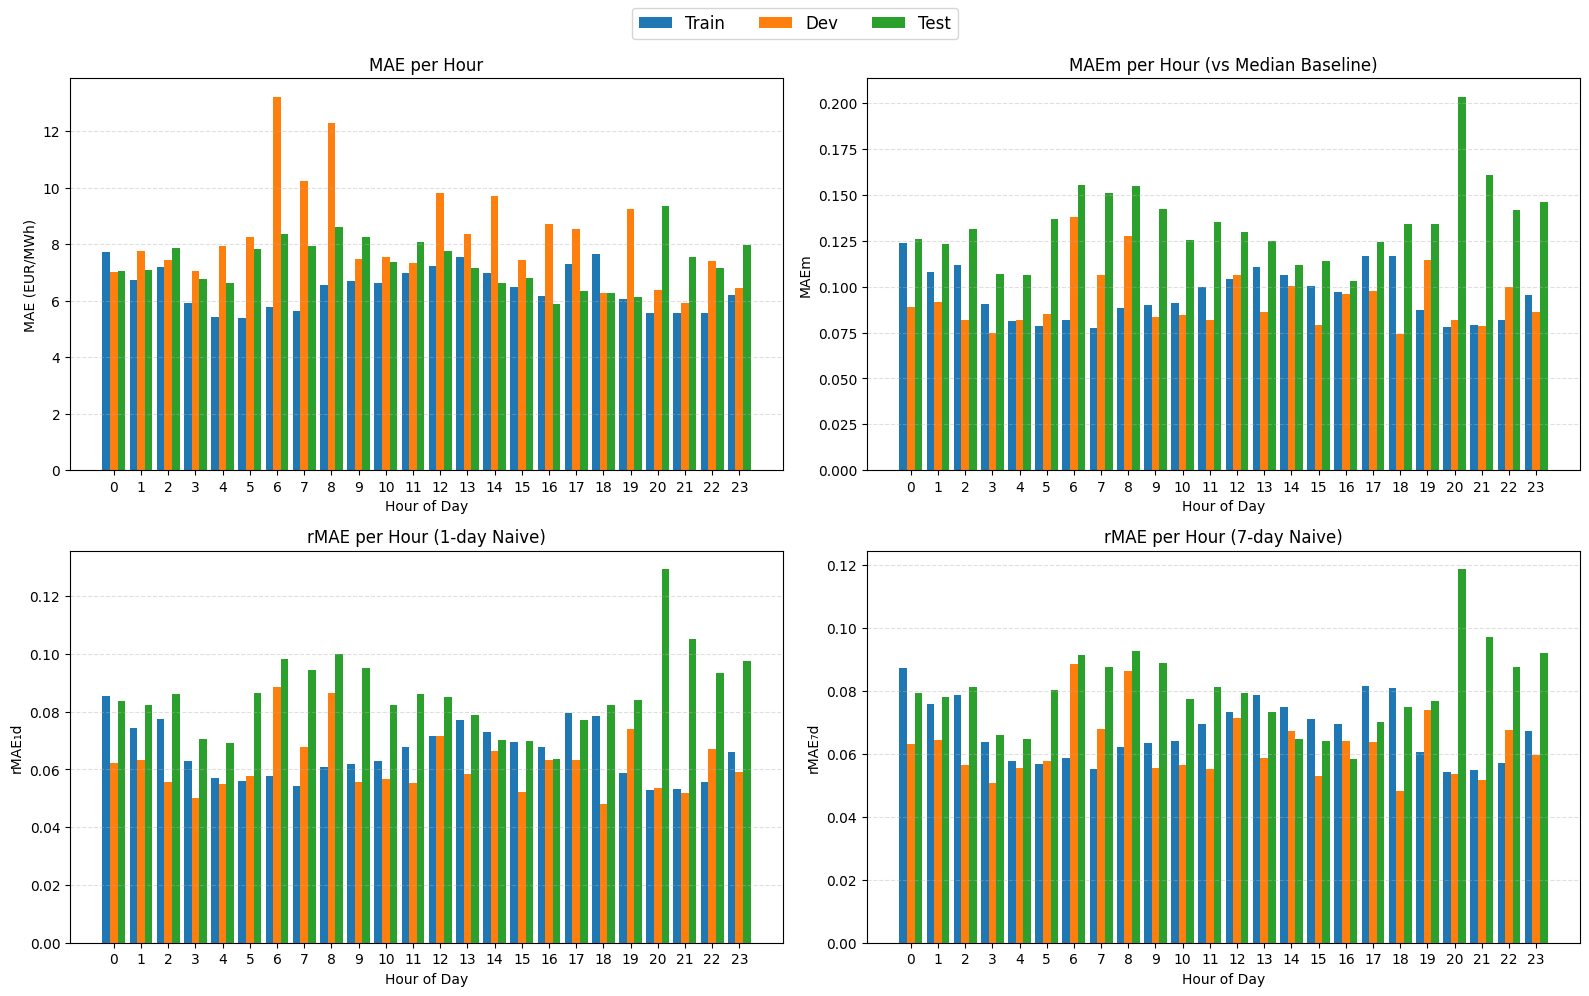

In [42]:

hours = np.arange(24)
width = 0.28

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# -------------------------------------
# 1) MAE per hour
# -------------------------------------
ax = axes[0, 0]
ax.bar(hours - width, mae_train_hour, width, label="Train",color='#1f77b4')
ax.bar(hours,         mae_dev_hour,   width, label="Dev", color='#ff7f0e')
ax.bar(hours + width, mae_test_hour,  width, label="Test", color='#2ca02c')
ax.set_title("MAE per Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("MAE (EUR/MWh)")
ax.set_xticks(hours)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# -------------------------------------
# 2) MAEm per hour
# -------------------------------------
ax = axes[0, 1]
ax.bar(hours - width, maem_train_hour, width, label="Train", color='#1f77b4')
ax.bar(hours,         maem_dev_hour,   width, label="Dev", color='#ff7f0e')
ax.bar(hours + width, maem_test_hour,  width, label="Test", color='#2ca02c')
ax.set_title("MAEm per Hour (vs Median Baseline)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("MAEm")
ax.set_xticks(hours)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# -------------------------------------
# 3) rMAE 1-day per hour
# -------------------------------------
ax = axes[1, 0]
ax.bar(hours - width, rmae1_train_hour, width, label="Train", color='#1f77b4')
ax.bar(hours,         rmae1_dev_hour,   width, label="Dev", color='#ff7f0e')
ax.bar(hours + width, rmae1_test_hour,  width, label="Test", color='#2ca02c')
ax.set_title("rMAE per Hour (1-day Naive)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("rMAE₁d")
ax.set_xticks(hours)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# -------------------------------------
# 4) rMAE 7-day per hour
# -------------------------------------
ax = axes[1, 1]
ax.bar(hours - width, rmae7_train_hour, width, label="Train", color='#1f77b4')
ax.bar(hours,         rmae7_dev_hour,   width, label="Dev", color='#ff7f0e')
ax.bar(hours + width, rmae7_test_hour,  width, label="Test", color='#2ca02c')
ax.set_title("rMAE per Hour (7-day Naive)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("rMAE₇d")
ax.set_xticks(hours)
ax.grid(axis='y', linestyle='--', alpha=0.4)

# -------------------------------------
# Final formatting
# -------------------------------------
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


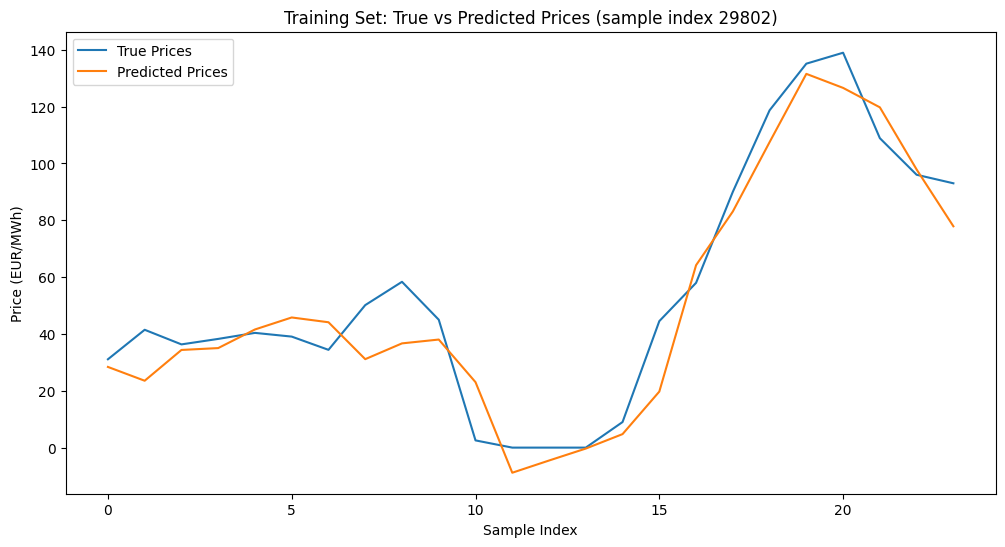

In [47]:
#Plot on the training set
plt.figure(figsize=(12,6))
idx=np.random.randint(0, len(eval_res_train["predictions"])-24)
plt.plot(y_train[idx:idx+24], label="True Prices")
plt.plot(eval_res_train["predictions"][idx:idx+24], label="Predicted Prices")
plt.title("Training Set: True vs Predicted Prices (sample index {})".format(idx))
plt.xlabel("Sample Index")
plt.ylabel("Price (EUR/MWh)")
plt.legend()
plt.show()

In [38]:
# -----------------------------
# Hyperparameter Tuning (clean)
# -----------------------------

results = {}   # store all results
cnn_values = [16, 32, 64]
dropout_values = [0.1, 0.3, 0.5]

for cnn in cnn_values:
    for d in dropout_values:

        print("="*60)
        print(f"Training with cnn={cnn}  | dropout={d}")
        print("="*60)

        model, train_hist, val_hist = run_full_train(
        Xrt_train_norm, y_train_norm,
        Xrt_dev_norm,   y_dev_norm,
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"],
        dropout=d,
        use_batchnorm=params["use_batchnorm"],
        leaky_alpha=params["leaky_alpha"],
        learning_rate=params["learning_rate"],
        weight_decay=params["weight_decay"],
        l1_lambda=params["l1_lambda"],
        batch_size=params["batch_size"],
        epochs=params["epochs"],
        cnn_channels=cnn,    # ← ADDED
        verbose_freq=1
    )

        print("Evaluating on dev set...")
        eval_res_dev = evaluate_model(
            model,
            Xrt_dev_norm,
            y_dev_norm,
            y1d_dev,
            y7d_dev,
            stats_dict,
            batch_size=256,
            device=device
        )

        # store clean results
        results[(cnn, d)] = {
            "MAE"   : eval_res_dev["MAE"],
            "MAEm"  : eval_res_dev["MAEm"],
            "rMAE1" : eval_res_dev["rMAE_1d"],
            "rMAE7" : eval_res_dev["rMAE_7d"],
        }

# -----------------------------
# Extract best configurations
# -----------------------------
min_mae   = min(v["MAE"]   for v in results.values())
min_maem  = min(v["MAEm"]  for v in results.values())
min_rmae1 = min(v["rMAE1"] for v in results.values())
min_rmae7 = min(v["rMAE7"] for v in results.values())

best_configs_mae   = [k for k,v in results.items() if v["MAE"]   == min_mae]
best_configs_maem  = [k for k,v in results.items() if v["MAEm"]  == min_maem]
best_configs_rmae1 = [k for k,v in results.items() if v["rMAE1"] == min_rmae1]
best_configs_rmae7 = [k for k,v in results.items() if v["rMAE7"] == min_rmae7]

print("\n=========== BEST CONFIGURATIONS ===========")
print(f"Best MAE ({min_mae:.4f}):            {best_configs_mae}")
print(f"Best MAEm ({min_maem:.4f}):          {best_configs_maem}")
print(f"Best rMAE-1d ({min_rmae1:.4f}):       {best_configs_rmae1}")
print(f"Best rMAE-7d ({min_rmae7:.4f}):       {best_configs_rmae7}")
print("==========================================\n")


Training with cnn=16  | dropout=0.1
SimpleRNN(
  (cnn_block1): Sequential(
    (0): Conv1d(10, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): LeakyReLU(negative_slope=0.08954143004580317)
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_block2): Sequential(
    (0): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): LeakyReLU(negative_slope=0.08954143004580317)
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(16, 128, batch_first=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (act): LeakyReLU(negative_slope=0.08954143004580317)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)
Epoch 001 | Train MAE: 0.2940 | Val MAE: 0.1841 | LR: 1.727766e-03
Epoch 002 | Train MAE: 0.1305 | Val MAE: 0.1429 | LR: 1.720581e-03
Epoch 003 | Train MAE: 0.1109 | Val MAE: 0.1268 | LR: 1.708654e-03
Epoch 00

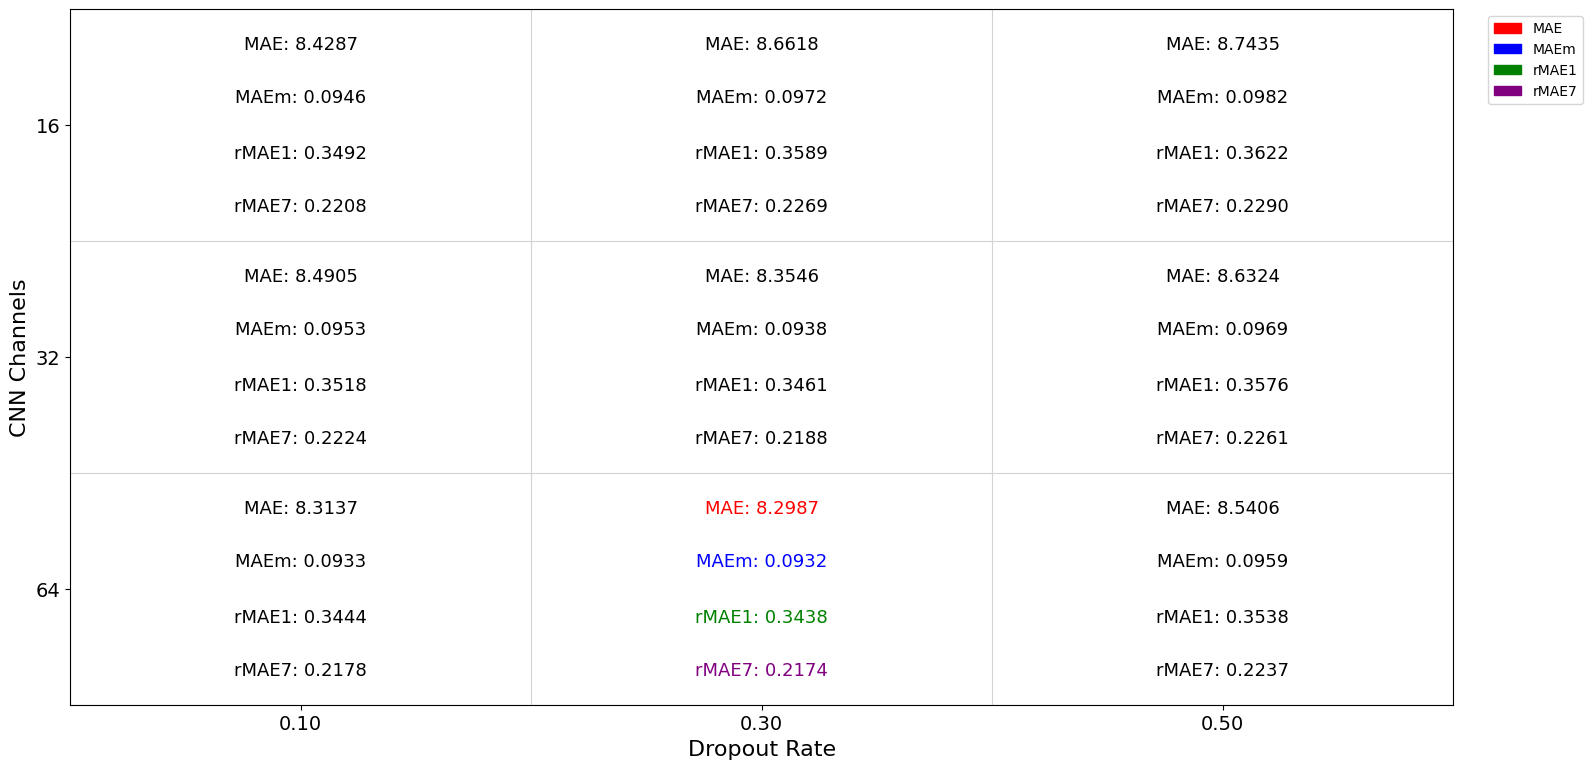

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ----------------------------------------------------
# 1. Extract axes: learning rates and lambdas
# ----------------------------------------------------
cnn = sorted({cnn for (cnn, _) in results.keys()})
dropouts = sorted({d for (_, d) in results.keys()})

metric_keys = ["MAE", "MAEm", "rMAE1", "rMAE7"]

# ----------------------------------------------------
# 2. Allocate grid for metrics and cell-text
# ----------------------------------------------------
grid = {mk: np.full((len(cnn), len(dropouts)), np.nan, dtype=float)
        for mk in metric_keys}

cell_text = [["" for _ in dropouts] for _ in cnn]

# ----------------------------------------------------
# 3. Fill matrices
# ----------------------------------------------------
for (cnn_val, dropout_val), ev in results.items():
    i = cnn.index(cnn_val)
    j = dropouts.index(dropout_val)

    for mk in metric_keys:
        grid[mk][i, j] = ev[mk]

    cell_text[i][j] = "\n".join(f"{mk}: {ev[mk]:.4f}" for mk in metric_keys)

# ----------------------------------------------------
# 4. Compute minima
# ----------------------------------------------------
min_positions = {}
for mk in metric_keys:
    mat = grid[mk]
    if np.isnan(mat).all():
        min_positions[mk] = []
        continue
    min_val = np.nanmin(mat)
    rows, cols = np.where(np.isclose(mat, min_val, atol=1e-12))
    min_positions[mk] = list(zip(rows, cols))

# ----------------------------------------------------
# 5. Plot
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 6 + 0.6 * len(cnn)))

ax.set_xlim(-0.5, len(dropouts) - 0.5)
ax.set_ylim(len(cnn) - 0.5, -0.5)

ax.set_xticks(range(len(dropouts)))
ax.set_xticklabels([f"{d:.2f}" for d in dropouts], fontsize=14)

ax.set_yticks(range(len(cnn)))
ax.set_yticklabels([f"{c}" for c in cnn], fontsize=14)
ax.set_xlabel("Dropout Rate", fontsize=16)
ax.set_ylabel("CNN Channels", fontsize=16)

# grid lines
for x in range(len(dropouts) + 1):
    ax.axvline(x - 0.5, color="lightgray", linewidth=0.8)
for y in range(len(cnn) + 1):
    ax.axhline(y - 0.5, color="lightgray", linewidth=0.8)

# colors
colors = ["red", "blue", "green", "purple"]
metric_colors = {metric_keys[i]: colors[i] for i in range(len(metric_keys))}
legend_patches = [patches.Patch(color=metric_colors[mk], label=mk)
                  for mk in metric_keys]

# annotation offsets
y_offsets = [-0.35, -0.12, 0.12, 0.35]

# ----------------------------------------------------
# 6. Annotate cells
# ----------------------------------------------------
for i in range(len(cnn)):
    for j in range(len(dropouts)):
        lines = cell_text[i][j].split("\n")
        for k, mk in enumerate(metric_keys):
            color = metric_colors[mk] if (i, j) in min_positions[mk] else "black"
            ax.text(j, i + y_offsets[k],
                    lines[k],
                    ha="center", va="center",
                    fontsize=13, color=color)

ax.legend(handles=legend_patches, bbox_to_anchor=(1.02, 1),
          loc="upper left")

plt.tight_layout()
plt.show()


In [48]:
def objective(trial):

    # --- Hyperparameters to tune ---
    use_batchnorm = trial.suggest_categorical("use_batchnorm", [True, False])
    leaky_alpha   = trial.suggest_float("leaky_alpha", 0.01, 0.2)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    l1_lambda     = trial.suggest_float("l1_lambda", 1e-7, 1e-3, log=True)
    batch_size    = trial.suggest_categorical("batch_size", [64, 128, 256])
    epochs        =40
    dropout       = trial.suggest_float("dropout", 0.0, 0.5)
    cnn_channels  = trial.suggest_categorical("cnn_channels", [16, 32, 64, 128])

    model, train_hist, val_hist = run_full_train(
        Xrt_train_norm, y_train_norm,
        Xrt_dev_norm,   y_dev_norm,
        dropout=dropout,
        use_batchnorm=use_batchnorm,
        leaky_alpha=leaky_alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        l1_lambda=l1_lambda,
        batch_size=batch_size,
        epochs=epochs,
        cnn_channels=cnn_channels,
        verbose_freq=9
    )


    # --- Evaluate on dev set ---
    metrics = evaluate_model(
        model,
        Xrt_dev_norm,
        y_dev_norm,
        y1d_dev,         # your baseline arrays
        y7d_dev,
        stats_dict,      # contains mean/std for denormalization
        batch_size=params["batch_size"],
        device=device
    )

    mae     = metrics["MAE"]
    maem    = metrics["MAEm"]
    r1      = metrics["rMAE_1d"]
    r7      = metrics["rMAE_7d"]

    return mae, maem, r1, r7


# --- Run the multi-objective study ---
study = optuna.create_study(
    directions=["minimize", "minimize", "minimize", "minimize"],
    study_name="FR_LMP_LSTM_TUNING"
)

study.optimize(objective, n_trials=20)

best_trials = study.best_trials
print(f"Found {len(best_trials)} Pareto-optimal trials.\n")

for t in best_trials:
    print("Values:", t.values)
    print("Params:", t.params)
    print("-" * 60)


[I 2025-12-04 00:02:17,065] A new study created in memory with name: FR_LMP_LSTM_TUNING


SimpleCNN(
  (cnn_block1): Sequential(
    (0): Conv1d(10, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_block2): Sequential(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dropout_cnn): Dropout(p=0.4340926467038844, inplace=False)
  (fc1): Linear(in_features=5376, out_features=128, bias=True)
  (bn_fc1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): LeakyReLU(negative_slope=0.027250056439899743)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)
Epoch 001 | Train MAE: 0.3041 | Val MAE: 0.1855 | LR: 2.517184e-03
Epoch 010 | Train MAE: 0.1333 | Val MAE: 0.1246 | LR: 2.188450e-03
Epoch 019 | Train MAE: 0.1184 | Val MAE: 0.1039 | LR: 1.475371e-03
Epoch 028 | Train MAE: 0.1099 | Val MAE: 0.0969 | LR: 7.196459e-04
Epoch 037 | 

[I 2025-12-04 00:02:51,908] Trial 0 finished with values: [9.035535635706601, 0.10143795055241413, 0.37434399608468744, 0.23666130503583271] and parameters: {'use_batchnorm': True, 'leaky_alpha': 0.027250056439899743, 'learning_rate': 0.002520680833163969, 'weight_decay': 7.722082401547339e-05, 'l1_lambda': 1.4451433495246284e-06, 'batch_size': 256, 'dropout': 0.4340926467038844, 'cnn_channels': 128}.


MAE: 9.0355 | MAEm: 0.1014 | rMAE-1d: 0.3743 | rMAE-7d: 0.2367
SimpleCNN(
  (cnn_block1): Sequential(
    (0): Conv1d(10, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_block2): Sequential(
    (0): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dropout_cnn): Dropout(p=0.42456870709005695, inplace=False)
  (fc1): Linear(in_features=672, out_features=16, bias=True)
  (act): LeakyReLU(negative_slope=0.01036107654139713)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)
Epoch 001 | Train MAE: 0.1977 | Val MAE: 0.1489 | LR: 3.222013e-03
Epoch 010 | Train MAE: 0.1272 | Val MAE: 0.1215 | LR: 2.801231e-03
Epoch 019 | Train MAE: 0.1178 | Val MAE: 0.1137 | LR: 1.888485e-03
Epoch 028 | Train MAE: 0.1112 | Val MAE: 0.1057 | LR: 9.211516e-04
Epoch 037 | Train MAE: 0.1045 | Val MAE: 0.0908 

[I 2025-12-04 00:03:52,330] Trial 1 finished with values: [9.046915079504831, 0.10156570252018428, 0.3748154486511315, 0.23695935864642648] and parameters: {'use_batchnorm': False, 'leaky_alpha': 0.01036107654139713, 'learning_rate': 0.0032264884938769008, 'weight_decay': 0.0008363006377217382, 'l1_lambda': 2.540352010714332e-05, 'batch_size': 64, 'dropout': 0.42456870709005695, 'cnn_channels': 16}.


...

MAE: 8.3477 | MAEm: 0.0937 | rMAE-1d: 0.3458 | rMAE-7d: 0.2186
SimpleCNN(
  (cnn_block1): Sequential(
    (0): Conv1d(10, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_block2): Sequential(
    (0): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dropout_cnn): Dropout(p=0.11412951498699775, inplace=False)
  (fc1): Linear(in_features=672, out_features=16, bias=True)
  (act): LeakyReLU(negative_slope=0.06576804804964122)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)
Epoch 001 | Train MAE: 0.2858 | Val MAE: 0.2113 | LR: 2.298973e-04
Epoch 010 | Train MAE: 0.1186 | Val MAE: 0.1288 | LR: 1.998736e-04
Epoch 019 | Train MAE: 0.1042 | Val MAE: 0.1137 | LR: 1.347473e-04
Epoch 028 | Train MAE: 0.0968 | Val MAE: 0.1073 | LR: 6.572608e-05
Epoch 037 | Train MAE: 0.0945 | Val MAE: 0.1052 

[I 2025-12-04 00:16:21,498] Trial 18 finished with values: [10.228543755538, 0.1148313235130446, 0.42377055417099624, 0.26790891114807003] and parameters: {'use_batchnorm': False, 'leaky_alpha': 0.06576804804964122, 'learning_rate': 0.0002302166416480206, 'weight_decay': 0.00038296091622809074, 'l1_lambda': 3.5483954280703033e-07, 'batch_size': 128, 'dropout': 0.11412951498699775, 'cnn_channels': 16}.


MAE: 10.2285 | MAEm: 0.1148 | rMAE-1d: 0.4238 | rMAE-7d: 0.2679
SimpleCNN(
  (cnn_block1): Sequential(
    (0): Conv1d(10, 16, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (cnn_block2): Sequential(
    (0): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dropout_cnn): Dropout(p=0.07992512405321567, inplace=False)
  (fc1): Linear(in_features=672, out_features=16, bias=True)
  (act): LeakyReLU(negative_slope=0.19854699357218145)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)
Epoch 001 | Train MAE: 0.1738 | Val MAE: 0.1549 | LR: 2.096107e-03
Epoch 010 | Train MAE: 0.0933 | Val MAE: 0.0956 | LR: 1.822364e-03
Epoch 019 | Train MAE: 0.0863 | Val MAE: 0.0901 | LR: 1.228569e-03
Epoch 028 | Train MAE: 0.0819 | Val MAE: 0.0859 | LR: 5.992628e-04
Epoch 037 | Train MAE: 0.0785 | Val MAE: 0.0852

[I 2025-12-04 00:17:54,275] Trial 19 finished with values: [8.249047772265557, 0.09260840018391873, 0.34175965116670026, 0.21606139246161316] and parameters: {'use_batchnorm': False, 'leaky_alpha': 0.19854699357218145, 'learning_rate': 0.002099018726128175, 'weight_decay': 3.190362533518615e-05, 'l1_lambda': 2.213343947356139e-05, 'batch_size': 64, 'dropout': 0.07992512405321567, 'cnn_channels': 16}.


MAE: 8.2490 | MAEm: 0.0926 | rMAE-1d: 0.3418 | rMAE-7d: 0.2161
Found 1 Pareto-optimal trials.

Values: [8.249047772265557, 0.09260840018391873, 0.34175965116670026, 0.21606139246161316]
Params: {'use_batchnorm': False, 'leaky_alpha': 0.19854699357218145, 'learning_rate': 0.002099018726128175, 'weight_decay': 3.190362533518615e-05, 'l1_lambda': 2.213343947356139e-05, 'batch_size': 64, 'dropout': 0.07992512405321567, 'cnn_channels': 16}
------------------------------------------------------------
